# Notebook 02 — Modélisation baseline

Étape 2 du projet (PDF tâches 6 à 11) : construire un modèle de scoring du défaut de crédit.

Notebook autonome : tout le code nécessaire est dans le notebook.

Plan :
1. Chargement des données et split train / val / test
2. Pipeline de préparation (tâche 6)
3. Métriques adaptées au déséquilibre (tâche 7)
4. Baseline : régression logistique + gestion du déséquilibre (tâches 8-9)
5. Modèle amélioré (tâche 9)
6. Seuil de décision / top K% (tâche 10)

La sauvegarde du modèle et le fichier de scoring (tâche 11) seront repris dans les scripts `src/train.py` et `src/infer.py` une fois les choix validés ici.

## 1. Chargement des données et split

- Drop immédiat de la colonne de leakage `predicted_default_payment_next_month` (jamais en feature).
- Split stratifié 72 / 10 / 18 (protocole défini au notebook 01, section 6.1), en deux coupes :
  le test (18%) est isolé en premier, puis la validation est prélevée dans les 82% restants.
  0.10 du total = 0.10 / 0.82 du restant, d'où le recalcul de `val_ratio`.

In [53]:
# Verification du kernel (doit pointer vers .venv du projet)
import sys
print(sys.executable)

c:\Dev\ProjetGenAIDataGong\.venv\Scripts\python.exe


In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Style graphiques
sns.set_theme(style="whitegrid", palette="muted")

url = "./../data/raw/Credit_card_default.csv"
print(f"URL du fichier csv: {url}")
df = pd.read_csv(url)
# - Leak and Drop de la colonne "predicted_default_payment_next_month"
df_leak = df["predicted_default_payment_next_month"].copy()
df = df.drop(columns=["predicted_default_payment_next_month"])

# Constantes (protocole notebook 01, section 6.1)
TARGET = "default_payment_next_month"
ID_COL = "id"
TEST_SIZE = 0.18
VAL_SIZE = 0.10
RANDOM_STATE = 42

X = df.drop(columns=[TARGET])
y = df[TARGET]

# Coupe 1 : test mis de cote (touche une seule fois, a la fin)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

# Coupe 2 : 0.10 du total = 0.10 / 0.82 du restant
val_ratio = VAL_SIZE / (1 - TEST_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp, y_tmp, test_size=val_ratio, stratify=y_tmp, random_state=RANDOM_STATE
)

print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")
for nom, X_, y_ in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{nom:5s} : {len(X_):4d} lignes ({len(X_)/len(df):.1%}) — taux défaut {y_.mean():.3f}")

URL du fichier csv: ./../data/raw/Credit_card_default.csv
Dimensions du dataset : 2965 lignes x 25 colonnes
train : 2134 lignes (72.0%) — taux défaut 0.214
val   :  297 lignes (10.0%) — taux défaut 0.215
test  :  534 lignes (18.0%) — taux défaut 0.213


## 2. Pipeline de préparation (tâche 6)

Traitement par type de colonne :

- `id` : écartée (aucun sens prédictif), mais conservée dans les DataFrames pour le fichier de scoring final.
- `sex`, `education_level`, `marital_status` : codes catégoriels sans ordre → recodage des valeurs hors documentation en "autres", puis one-hot encoding.
- `pay_0..pay_6` : codes ordonnés (retard croissant) → gardés numériques (choix assumé).
- Numériques (`limit_balance`, `age`, `bill_amt_*`, `pay_amt_*`) : `StandardScaler`, nécessaire pour la régression logistique.

Anti-fuite : le scaler et l'encodeur *apprennent* des statistiques (moyennes, catégories). Ils sont donc dans le `Pipeline`, fitté sur le train seul. Le recodage "autres" est un mapping fixe (rien d'appris) mais on le met aussi dans le pipeline via `FunctionTransformer` : le modèle sauvegardé saura ainsi traiter des données brutes telles quelles.

In [55]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler


def recode_categories(X):
    """Regroupe les codes hors documentation en 'autres' (mapping fixe)."""
    X = X.copy()
    # education_level : 1=etudes sup, 2=universite, 3=lycee, 4=autres ; 0/5/6 -> 4
    X["education_level"] = X["education_level"].replace({0: 4, 5: 4, 6: 4})
    # marital_status : 1=marie, 2=celibataire, 3=autres ; 0 -> 3
    X["marital_status"] = X["marital_status"].replace({0: 3})
    return X


CAT_COLS = ["sex", "education_level", "marital_status"]
NUM_COLS = [c for c in X_train.columns if c not in CAT_COLS + [ID_COL]]

# ColumnTransformer : chaque famille de colonnes recoit son traitement,
# tout ce qui n'est pas liste (id) est ecarte par remainder="drop"
preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CAT_COLS),
        ("num", StandardScaler(), NUM_COLS),
    ],
    remainder="drop",
)

# Pipeline de preparation complet (le modele est ajoute en dernier maillon en sections 4-5)
prep_pipeline = Pipeline([
    ("recode", FunctionTransformer(recode_categories)),
    ("prep", preprocess),
])

# Sortie pandas : les transformers renvoient des DataFrames avec noms de colonnes
prep_pipeline.set_output(transform="pandas")

# Verification : fit sur le train SEUL, transform de la validation
Xt_train = prep_pipeline.fit_transform(X_train)
Xt_val = prep_pipeline.transform(X_val)
print(f"train transforme : {Xt_train.shape} ({len(NUM_COLS)} num + one-hot des {len(CAT_COLS)} cat)")
print(f"val   transforme : {Xt_val.shape}")
Xt_train.head()

train transforme : (2134, 29) (20 num + one-hot des 3 cat)
val   transforme : (297, 29)


,cat__sex_1,cat__sex_2,cat__education_level_1,cat__education_level_2,cat__education_level_3,cat__education_level_4,cat__marital_status_1,cat__marital_status_2,cat__marital_status_3,num__limit_balance,...,num__bill_amt_3,num__bill_amt_4,num__bill_amt_5,num__bill_amt_6,num__pay_amt_1,num__pay_amt_2,num__pay_amt_3,num__pay_amt_4,num__pay_amt_5,num__pay_amt_6
1354,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,-0.032745,...,1.458906,1.684128,1.648538,1.769211,0.043390,-0.204498,0.030184,0.024087,0.107479,0.000175
296,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.778836,...,2.130843,2.340801,2.673352,2.711996,0.156211,0.098398,0.986484,0.418982,0.386059,0.261239
475,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.778836,...,1.503173,1.522054,1.604098,1.553030,-0.014718,-0.024685,0.044317,0.037899,0.038252,0.036811
2675,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.778836,...,2.241688,-0.668949,-0.698875,-0.686562,9.434964,5.798395,-0.173795,-0.319987,-0.289149,-0.154801
1509,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.454204,...,1.692237,1.348080,1.549786,1.209471,-0.291634,-0.204169,-0.359469,0.003941,0.038322,9.297125


### Visualisation du pipeline

Le diagramme interactif ci-dessous montre le pipeline complet tel que sklearn l'exécute :
recodage → ColumnTransformer (one-hot + scaler, id écarté) → modèle.

In [56]:
from sklearn import set_config
set_config(display="diagram")

# Affichage interactif du pipeline (cliquer sur chaque maillon pour le deplier).
# Le modele (sections 4-5) viendra s'ajouter comme dernier maillon.
prep_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('recode', ...), ('prep', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](24,)","['id','limit_balance','sex',...,'pay_amt_4','pay_amt_5','pay_amt_6']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,24
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function rec...00242FC21E5C0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


## 3. Métriques (tâche 7)

- **PR-AUC** (prioritaire) : compromis précision/rappel sur tous les seuils. Référence d'un modèle aléatoire = taux de défaut (~0.214), pas 0.5.
- **Recall@topK** : logique métier — si on relance les K% clients les plus risqués, quelle part des vrais défauts capte-t-on ? C'est un tri par probabilité, pas un seuil.
- Matrice de confusion + precision/recall à un seuil donné, pour visualiser faux positifs / faux négatifs.
- Accuracy exclue : trompeuse à 21.4% de défaut (prédire toujours 0 donne 78.6%).

La fonction `evaluer` sera réutilisée pour chaque modèle des sections 4 et 5.

In [57]:
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_score,
    recall_score,
)


def recall_at_topk(y_true, y_proba, k=0.20):
    """Part des vrais defauts captes en ciblant les k% clients les plus risques."""
    n_top = int(len(y_true) * k)
    ordre = np.argsort(y_proba)[::-1]          # indices tries par proba decroissante
    y_top = np.asarray(y_true)[ordre[:n_top]]  # vraies etiquettes du top k%
    return y_top.sum() / np.asarray(y_true).sum()


def evaluer(nom, y_true, y_proba, seuil=0.5, k=0.20):
    """Affiche les metriques cles d'un modele (PDF tache 7). Retourne la PR-AUC."""
    y_pred = (y_proba >= seuil).astype(int)
    pr_auc = average_precision_score(y_true, y_proba)
    print(f"--- {nom} ---")
    print(f"PR-AUC          : {pr_auc:.3f}  (aleatoire ~ {np.mean(y_true):.3f})")
    print(f"recall@top{int(k*100):d}%    : {recall_at_topk(y_true, y_proba, k):.3f}")
    print(f"seuil {seuil} -> precision : {precision_score(y_true, y_pred):.3f} | recall : {recall_score(y_true, y_pred):.3f}")
    print("matrice de confusion [[VN FP] [FN VP]] :")
    print(confusion_matrix(y_true, y_pred))
    return pr_auc


# Controle rapide : des probas aleatoires doivent donner PR-AUC ~ 0.214 et recall@top20% ~ 0.20
rng = np.random.default_rng(RANDOM_STATE)
proba_hasard = rng.random(len(y_val))
_ = evaluer("controle : probas aleatoires", y_val, proba_hasard)

--- controle : probas aleatoires ---
PR-AUC          : 0.236  (aleatoire ~ 0.215)
recall@top20%    : 0.203
seuil 0.5 -> precision : 0.211 | recall : 0.469
matrice de confusion [[VN FP] [FN VP]] :
[[121 112]
 [ 34  30]]


## 4. Baseline — régression logistique (tâches 8-9)

Deux variantes comparées sur la **validation** (le test reste intouché) :

- sans pondération : le modèle optimise l'erreur globale, dominée par la classe majoritaire (79% de non-défauts) ;
- `class_weight="balanced"` : chaque erreur sur un défaut pèse ~4.7x plus (ratio 79/21) pendant l'entraînement. Les données ne sont pas modifiées.

Attendu : la PR-AUC bouge peu (elle dépend du classement des probabilités), mais le recall au seuil 0.5 monte nettement — les probabilités sont décalées vers le haut pour la classe rare.

Chaque variante reçoit son propre pipeline (recodage + préparation + modèle) fitté sur le train seul.

In [58]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression


def make_logreg(class_weight=None):
    """Pipeline complet : recodage + preparation + regression logistique."""
    return Pipeline([
        ("recode", FunctionTransformer(recode_categories)),
        ("prep", clone(preprocess)),  # clone : chaque pipeline a sa propre copie
        ("clf", LogisticRegression(max_iter=1000, class_weight=class_weight,
                                   random_state=RANDOM_STATE)),
    ])


modeles = {}
for label, cw in [("logreg sans ponderation", None),
                  ("logreg class_weight=balanced", "balanced")]:
    model = make_logreg(cw)
    model.fit(X_train, y_train)
    proba_val = model.predict_proba(X_val)[:, 1]  # proba de la classe 1 (defaut)
    evaluer(label, y_val, proba_val)
    modeles[label] = model
    print()

--- logreg sans ponderation ---
PR-AUC          : 0.644  (aleatoire ~ 0.215)
recall@top20%    : 0.562
seuil 0.5 -> precision : 0.900 | recall : 0.281
matrice de confusion [[VN FP] [FN VP]] :
[[231   2]
 [ 46  18]]

--- logreg class_weight=balanced ---
PR-AUC          : 0.644  (aleatoire ~ 0.215)
recall@top20%    : 0.562
seuil 0.5 -> precision : 0.416 | recall : 0.734
matrice de confusion [[VN FP] [FN VP]] :
[[167  66]
 [ 17  47]]



## 5. Modèle amélioré — HistGradientBoosting (tâche 9)

Modèle à base d'arbres : il capte des interactions non linéaires invisibles pour la régression logistique.
Les arbres n'ont besoin ni de scaling ni de one-hot (ils coupent sur des seuils), mais on garde le même pipeline
pour comparer les deux modèles à traitement strictement égal.

Mêmes deux variantes (avec / sans `class_weight`), même évaluation sur la validation.

In [59]:
from sklearn.ensemble import HistGradientBoostingClassifier


def make_hgb(class_weight=None):
    """Pipeline complet : recodage + preparation + gradient boosting."""
    return Pipeline([
        ("recode", FunctionTransformer(recode_categories)),
        ("prep", clone(preprocess)),
        ("clf", HistGradientBoostingClassifier(class_weight=class_weight,
                                               random_state=RANDOM_STATE)),
    ])


for label, cw in [("hgb sans ponderation", None),
                  ("hgb class_weight=balanced", "balanced")]:
    model = make_hgb(cw)
    model.fit(X_train, y_train)
    proba_val = model.predict_proba(X_val)[:, 1]
    evaluer(label, y_val, proba_val)
    modeles[label] = model
    print()

--- hgb sans ponderation ---
PR-AUC          : 0.626  (aleatoire ~ 0.215)
recall@top20%    : 0.516
seuil 0.5 -> precision : 0.667 | recall : 0.469
matrice de confusion [[VN FP] [FN VP]] :
[[218  15]
 [ 34  30]]

--- hgb class_weight=balanced ---
PR-AUC          : 0.627  (aleatoire ~ 0.215)
recall@top20%    : 0.531
seuil 0.5 -> precision : 0.556 | recall : 0.547
matrice de confusion [[VN FP] [FN VP]] :
[[205  28]
 [ 29  35]]



### Courbes précision-rappel (validation)

La PR-AUC est l'aire sous ces courbes. Lecture : pour un recall donné (part des défauts captés),
quelle précision (part de vraies alertes parmi les relances) chaque modèle offre-t-il ?
La ligne grise est le niveau du hasard (taux de défaut).

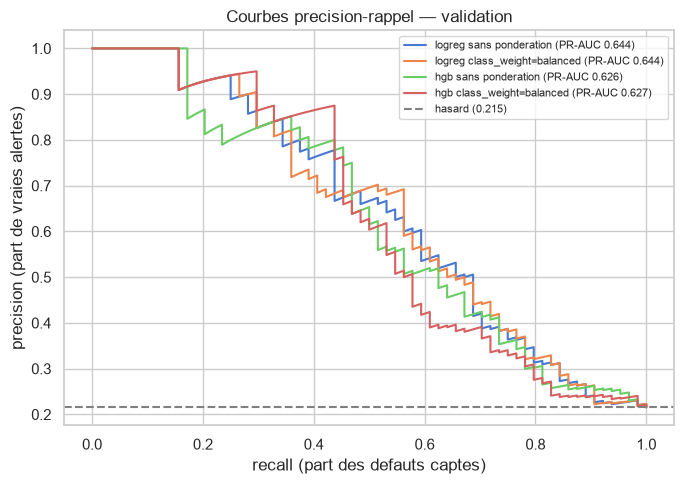

In [60]:
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(7, 5))
for label, model in modeles.items():
    proba = model.predict_proba(X_val)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, proba)
    plt.plot(rec, prec, lw=1.5, label=f"{label} (PR-AUC {average_precision_score(y_val, proba):.3f})")
plt.axhline(y_val.mean(), ls="--", color="gray", label=f"hasard ({y_val.mean():.3f})")
plt.xlabel("recall (part des defauts captes)")
plt.ylabel("precision (part de vraies alertes)")
plt.title("Courbes precision-rappel — validation")
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Matrices de confusion (validation, seuil 0.5)

Lecture : ligne = realite, colonne = prediction. En haut a droite les fausses alertes (FP),
en bas a gauche les defauts manques (FN) — l'erreur la plus couteuse pour le metier.

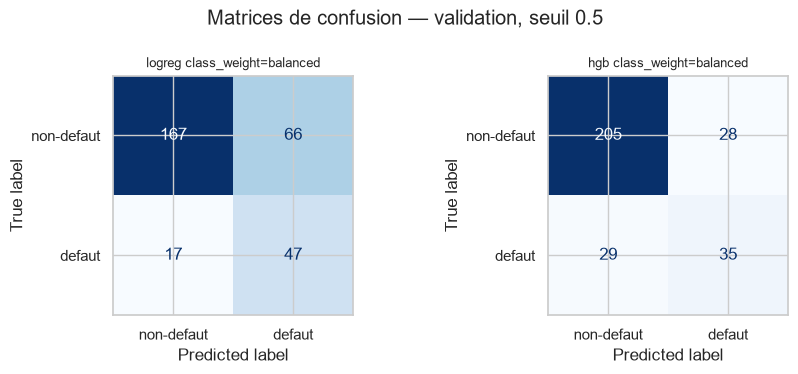

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, label in zip(axes, ["logreg class_weight=balanced", "hgb class_weight=balanced"]):
    proba = modeles[label].predict_proba(X_val)[:, 1]
    ConfusionMatrixDisplay.from_predictions(
        y_val, (proba >= 0.5).astype(int), ax=ax, colorbar=False, cmap="Blues",
        display_labels=["non-defaut", "defaut"],
    )
    ax.set_title(label, fontsize=9)
plt.suptitle("Matrices de confusion — validation, seuil 0.5")
plt.tight_layout()
plt.show()

### Comparaison des metriques par modele

Toutes les metriques du protocole, cote a cote. PR-AUC et recall@top20% dependent du classement
(insensibles a class_weight) ; precision/recall/F1 sont pris au seuil 0.5 et montrent le compromis.

                              pr_auc  precision  recall  f1_score  \
modele                                                              
logreg sans ponderation        0.644      0.900   0.281     0.429   
logreg class_weight=balanced   0.644      0.416   0.734     0.531   
hgb sans ponderation           0.626      0.667   0.469     0.550   
hgb class_weight=balanced      0.627      0.556   0.547     0.551   

                              recall@top20%  
modele                                       
logreg sans ponderation               0.562  
logreg class_weight=balanced          0.562  
hgb sans ponderation                  0.516  
hgb class_weight=balanced             0.531  


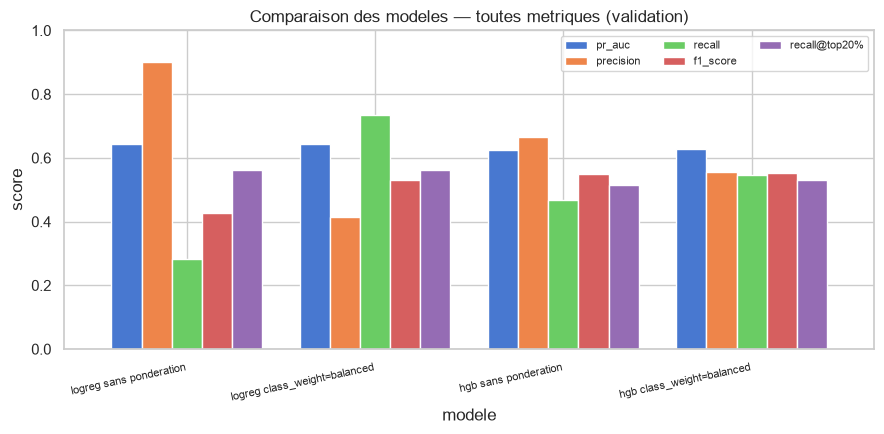

In [62]:
from sklearn.metrics import f1_score

lignes = []
for label, model in modeles.items():
    proba = model.predict_proba(X_val)[:, 1]
    pred = (proba >= 0.5).astype(int)
    lignes.append({
        "modele": label,
        "pr_auc": average_precision_score(y_val, proba),
        "precision": precision_score(y_val, pred),
        "recall": recall_score(y_val, pred),
        "f1_score": f1_score(y_val, pred),
        "recall@top20%": recall_at_topk(y_val, proba, 0.20),
    })
df_scores = pd.DataFrame(lignes).set_index("modele")
print(df_scores.round(3))

df_scores.plot.bar(figsize=(9, 4.5), width=0.8)
plt.title("Comparaison des modeles — toutes metriques (validation)")
plt.ylabel("score")
plt.ylim(0, 1)
plt.xticks(rotation=12, ha="right", fontsize=8)
plt.legend(fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

## 6. Seuil de décision / top K% (tâche 10)

Contexte métier (fil rouge) : la direction Recouvrement dispose d'un **budget de relance limité**,
qui permet de traiter environ **20% des clients** sur le trimestre. C'est cette contrainte qui fixe K,
pas un seuil de probabilité : on relance les 20% clients les plus risqués selon le modèle.

La courbe ci-dessous est une **analyse de sensibilité** : avec des hypothèses de coût
(relance 25 €, défaut manqué 1 000 €), elle montre ce que coûterait chaque niveau de budget K.
Avec ces hypothèses, le coût brut diminue encore au-delà de 20% — autrement dit, si le métier pouvait
augmenter la capacité de relance, ce serait rentable. Mais ces coûts supposent qu'une relance évite
toujours le défaut, ce qui est optimiste : la recommandation reste K = 20%, la courbe sert d'argument
pour une discussion budget avec le métier.

Le seuil de probabilité équivalent (quantile 80% des probas) est donné à titre indicatif : c'est lui
qu'on utiliserait en production pour un flux client par client.

PR-AUC validation par modele :
  0.644  logreg class_weight=balanced
  0.644  logreg sans ponderation
  0.627  hgb class_weight=balanced
  0.626  hgb sans ponderation

Modele retenu : logreg class_weight=balanced


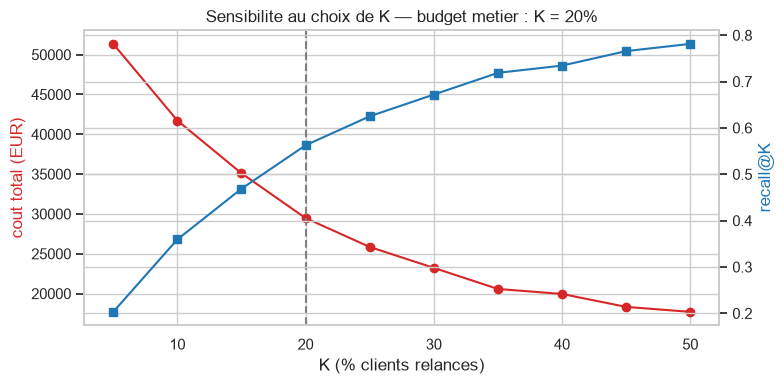

K retenu (budget) : 20% -> cout 29,475 EUR, recall 56.2%
Seuil de probabilite equivalent : 0.560
Note : le minimum de cout brut est a K = 50% — voir markdown ci-dessus.


In [63]:
# Choix du modele final : meilleure PR-AUC sur validation
pr_aucs = {}
for label, model in modeles.items():
    proba = model.predict_proba(X_val)[:, 1]
    pr_aucs[label] = average_precision_score(y_val, proba)
best_label = max(pr_aucs, key=pr_aucs.get)
best_model = modeles[best_label]
print("PR-AUC validation par modele :")
for label, v in sorted(pr_aucs.items(), key=lambda x: -x[1]):
    print(f"  {v:.3f}  {label}")
print(f"\nModele retenu : {best_label}")

# Decision : budget contraint — la capacite de relance du trimestre fixe K
K_BUDGET = 0.20       # 20% des clients relances (contrainte metier)

# Hypotheses de cout pour l'analyse de sensibilite (a ajuster avec le metier)
COUT_RELANCE = 25     # euros par client relance
COUT_DEFAUT = 1000    # euros par defaut manque

proba_val = best_model.predict_proba(X_val)[:, 1]
n = len(y_val)
y_val_arr = np.asarray(y_val)
ordre = np.argsort(proba_val)[::-1]

ks = np.arange(0.05, 0.55, 0.05)
couts, recalls = [], []
for k in ks:
    n_top = int(n * k)
    captes = y_val_arr[ordre[:n_top]].sum()
    manques = y_val_arr.sum() - captes
    couts.append(n_top * COUT_RELANCE + manques * COUT_DEFAUT)
    recalls.append(captes / y_val_arr.sum())

best_k = K_BUDGET
seuil_equiv = float(np.quantile(proba_val, 1 - best_k))
i_budget = int(np.argmin(np.abs(ks - K_BUDGET)))

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(ks * 100, couts, marker="o", color="tab:red")
ax1.set_xlabel("K (% clients relances)")
ax1.set_ylabel("cout total (EUR)", color="tab:red")
ax2 = ax1.twinx()
ax2.plot(ks * 100, recalls, marker="s", color="tab:blue")
ax2.set_ylabel("recall@K", color="tab:blue")
ax1.axvline(K_BUDGET * 100, ls="--", color="gray")
plt.title(f"Sensibilite au choix de K — budget metier : K = {K_BUDGET:.0%}")
plt.tight_layout()
plt.show()

print(f"K retenu (budget) : {K_BUDGET:.0%} -> cout {couts[i_budget]:,.0f} EUR, recall {recalls[i_budget]:.1%}")
print(f"Seuil de probabilite equivalent : {seuil_equiv:.3f}")
print(f"Note : le minimum de cout brut est a K = {ks[int(np.argmin(couts))]:.0%} — voir markdown ci-dessus.")

### Évaluation finale sur le test

Le jeu de test n'a servi à **aucun** choix (modèle, K, seuil). On l'utilise une seule fois,
ici, pour estimer la performance attendue en production.

In [64]:
proba_test = best_model.predict_proba(X_test)[:, 1]
_ = evaluer(f"FINAL sur test : {best_label}", y_test, proba_test, k=best_k)
print(f"\nrecall@top{best_k:.0%} sur test : {recall_at_topk(y_test, proba_test, k=best_k):.3f}")

--- FINAL sur test : logreg class_weight=balanced ---
PR-AUC          : 0.488  (aleatoire ~ 0.213)
recall@top20%    : 0.465
seuil 0.5 -> precision : 0.330 | recall : 0.667
matrice de confusion [[VN FP] [FN VP]] :
[[266 154]
 [ 38  76]]

recall@top20% sur test : 0.465


### Conclusion (à enrichir)

- Modèle retenu, K choisi et coût associé : voir sorties ci-dessus.
- Limites : dataset petit (2965 lignes), hypothèses de coût à valider avec le métier,
  pas de calibration des probabilités (piste notebook 03).
- Prochaine étape : factoriser l'entraînement du modèle retenu dans `src/train.py`
  et le scoring dans `src/infer.py` (tâche 11).